### ANÁLISIS DESCRIPTIVO DE Y PREPROCESAMIENTO DE INFORMACIÓN ENCUESTA SALUD BIENESTAR Y ENVEJECIMIENTO


In [4967]:
#importar librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings 
warnings.filterwarnings("ignore")

In [4968]:
#leer la base de datos
df = pd.read_csv('SABE.csv', encoding='latin-1')

In [4969]:
#borrar la columna que genera indexes
del df[df.columns[0]]

In [4970]:
df.head(2)

,hatrabajado,p228,ingresos,trabaja,p203,p204,p104,piso,hogar,vivienda,...,barthel_total,barthel_dic,lawton_total,total,cogtotal,qsm,orienttot,recall,counting,language
0,si,17,0-1SM,NaN,0,5,1,alto ingreso,propia,casa/apto,...,100,sano,0,27,sano,6,10,3,5,9
1,si,20,0-1SM,no,5,3,1,alto ingreso,propia,casa/apto,...,100,sano,0,24,enfermo,5,10,3,2,9


#### - Renombrar Columnas

In [4971]:
#renombrar columnas
df.rename(columns={'hatrabajado':'ha_trabajado','p228':'edad_primer_trabajo','p104':'area_vivienda','p203':'escolaridad_en_anos','p204':'grado_alcanzado','buscaayuda':'busca_ayuda','OH':'consumo_alcohol','arterialhypertension':'hipertension_arterial','recibir':'recibir_serv_salud','hafumado':'ha_fumado','rechazo':'robo','p139a':'num_personas_casa','vivienda':'tipo_vivienda','hogar':'vivienda','velmarch':'velocidad_marcha','gsi_anymax':'fuerza_presion','myocardial_infarction':'infarto_miocardio','mental_disease':'trastorno_mental','prob_audicion':'problemas_de_audicion', 'ecivil':'estado_civil','grupos':'participacion_en_grupos','p139':'num_personas_casa','p142a': 'grupo_etnico','p142b':'raza','p121':'sexo','p122edad':'edad','p420':'edad_desplazamiento','p421':'num_desplazamientos','economia15':'economia_familiar','salud15':'salud_adolescencia','salud30':'salud_30dias','oirenmultitudes':'oir_en_multitudes','protesisdental':'protesis_dental','miedoacaer':'miedo_a_caer','autosalud':'auto_salud','total': 'minimental_total','cogtotal':'alteracion_cognitiva','qsm':'queja_subjetiva','orienttot':'total_orientacion','recall':'total_recuerdo','language':'lenguaje','counting':'calculo'},inplace=True)

In [4972]:
#dataframe con columnas cambiadas
df.head(2)


,ha_trabajado,edad_primer_trabajo,ingresos,trabaja,escolaridad_en_anos,grado_alcanzado,area_vivienda,piso,vivienda,tipo_vivienda,...,barthel_total,barthel_dic,lawton_total,minimental_total,alteracion_cognitiva,queja_subjetiva,total_orientacion,total_recuerdo,calculo,lenguaje
0,si,17,0-1SM,NaN,0,5,1,alto ingreso,propia,casa/apto,...,100,sano,0,27,sano,6,10,3,5,9
1,si,20,0-1SM,no,5,3,1,alto ingreso,propia,casa/apto,...,100,sano,0,24,enfermo,5,10,3,2,9


## DESCRIPCIÓN DE VARIABLES


*  **Ingresos** 
    -   0-1 SM (Salario Minimo Colombiano)
    -	2-3SM  
    -	Maporor a 3SM

* **Material del piso de su hogar**
    -	Alto ingreso
    -	Bajo ingreso

* **Servicios**
    - 0 No tiene acceso
    - 5 Tiene acceso a todos los servicios
    
* **salud_30dias**
    - Durante los últimos 30 días, ¿usted ha tenido algún problema de salud? (si/no)

* **recibir_serv_salud**
    - ¿Recibió de su servicio de salud la atención solicitada para los problemas de salud que ha presentado? (si/no)

* **medicamentos**
    - ¿Pudo obtener los medicamentos o remedios recetados? (si/no)

* **paraclínicos**
    - ¿Se ha podido realizar los paraclínicos ordenados? (si/no)

* **busca_ayuda**
    - Sin estar enfermo, ¿usted busca los servicios de salud por lo menos una vez al año? (si/no)

* **consumo_alcohol**
    - 	ocasionalmente         
    -	2-6d/w (2 a 6 días por semana)        
    -	diario          
    -	nunca

* **vision**
    - buena
    - regular
    - mala

* **percepcion**
    - Considera que las personas de edad ocupan en la sociedad el lugar que realmente les corresponde (si/no) 

* **sexualidad**
    - ¿ Qué tan importante es la sexualidad en su vida? (importante/poco importante)

* **ancianitud**
  * ¿Se siente viejo? (si/no)

* **num_personas_casa**
    - ¿Cuántas personas viven con ud?

* **grupo_etnico**
    - Indígena
    - Gitano/ROM
    - Raizal del archipiélago de San Andrés y Providencia
    - Palenquero de San Basilio
    - Negro, afrodescendiente o afrocolombiano
    - Ninguno de los anteriores

* **maltrato**
    - En el último año ¿ha sido insultado o maltratado por un extraño? (si/no)

* **robo**
    - En el último año, ¿fue robado por un extraño? (si/no)

* **lastimado**

    - En el último año, ¿ha sido golpeado, herido o lastimado, por un extraño? 

* **rechazo**

  En su infancia, ¿alguna vez se sintió rechazado, discriminado, tratado mal? 
    -	Muchas veces
    -	Algunas veces
    -	Pocas veces
    -	Nunca


* **hambre15**
    - En sus primeros 15 años de su vida, ¿diría usted que hubo algún tiempo en que no comió lo suficiente y tuvo hambre?

* **testigo15**
    - En sus 15 años de su vida, ¿Presenció o fue testigo de violencia física entre parientes cercanos? 

* **auto_salud**
    - Autopercepción del estado de salud

* **voluntariado**

    - Durante el último año, ¿ha prestado algún servicio de forma voluntaria o gratuita a alguna organización? 

* **ayudainstitucion**

    - Durante el último año ¿recibió ud la ayuda de alguna institución u organización?

* **area_vivienda**

    - 1 Cabecera municipal
    - 2 a centro poblado
    - 3 a rural disperso

* **Piso**

    - alto: mármol, alfombra de pared a pared, baldosa y madera pulida o parqué
    - bajo : madera burda o tablón, cemento o gravilla, y tierra o arena.


## EXPLORACION POBLACIÓN Y VARIABLES CON DATOS ORIGINALES

### Datos demográficos y socioeconómicos

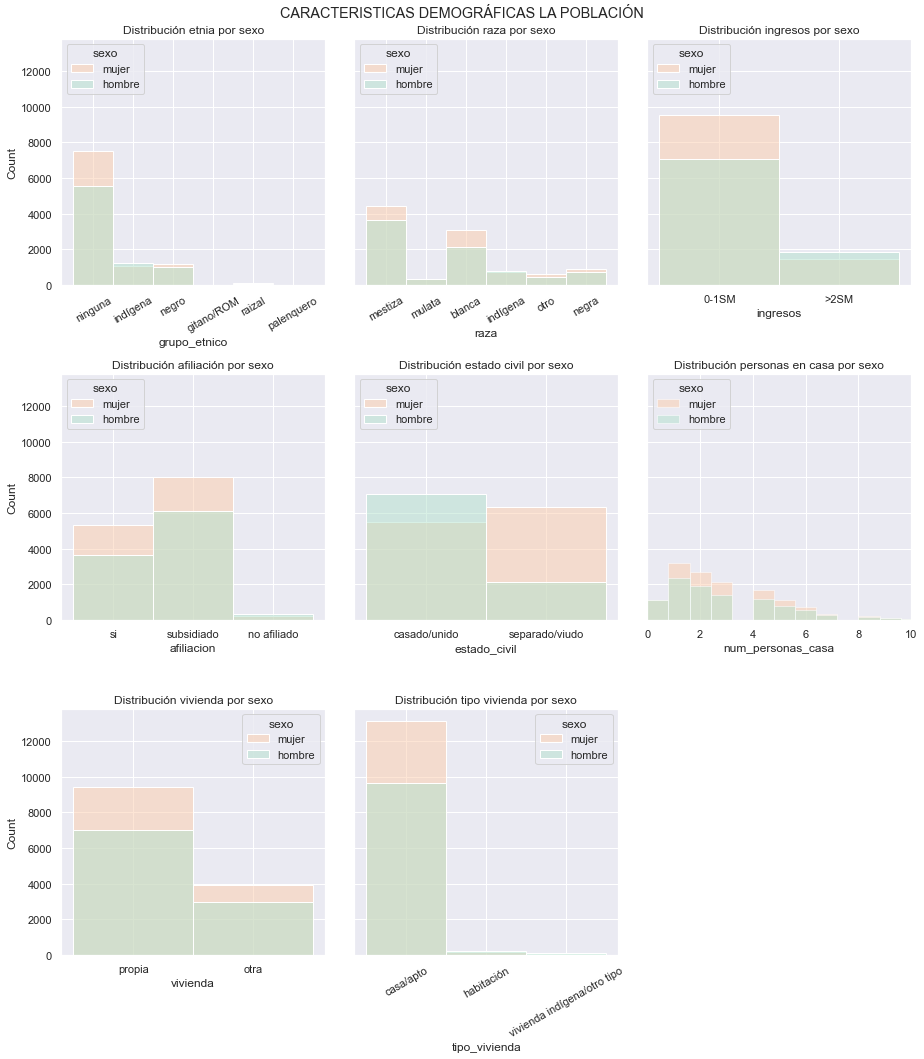

In [4973]:
fig, axes = plt.subplots(3, 3, figsize=(13, 15), sharey=True)
fig.suptitle('CARACTERISTICAS DEMOGRÁFICAS LA POBLACIÓN')

# Etnia
sns.histplot(ax=axes[0][0],x= df['grupo_etnico'], hue= df['sexo'], palette= 'Pastel2')
axes[0][0].set_title('Distribución etnia por sexo')
axes[0][0].tick_params(axis='x', rotation= 30)
axes[0][0].legend(title='sexo', loc='upper left', labels=['mujer', 'hombre'])

# Raza
sns.histplot(ax=axes[0][1],x= df['raza'], hue= df['sexo'], palette= 'Pastel2',binwidth = 0.8)
axes[0][1].set_title('Distribución raza por sexo')
axes[0][1].tick_params(axis='x', rotation= 30)
axes[0][1].legend(title='sexo', loc='upper left', labels=['mujer', 'hombre'])

#Ingresos
sns.histplot(ax=axes[0][2],x= df['ingresos'], hue= df['sexo'], palette= 'Pastel2')
axes[0][2].set_title('Distribución ingresos por sexo')
axes[0][2].legend(title='sexo', loc='upper left', labels=['mujer', 'hombre'])


#afiliacion
sns.histplot(ax=axes[1][0],x= df['afiliacion'], hue= df['sexo'], palette= 'Pastel2')
axes[1][0].set_title('Distribución afiliación por sexo')
axes[1][0].legend(title='sexo', loc='upper left', labels=['mujer', 'hombre'])

#Estado civil
sns.histplot(ax=axes[1][1],x= df['estado_civil'], hue= df['sexo'], palette= 'Pastel2')
axes[1][1].set_title('Distribución estado civil por sexo')
axes[1][1].legend(title='sexo', loc='upper left', labels=['mujer', 'hombre'])

#Num personas en casa
sns.histplot(ax=axes[1][2],x= df['num_personas_casa'], hue= df['sexo'], palette= 'Pastel2',binwidth = 0.8)
axes[1][2].set_xlim(0,10)
axes[1][2].set_title('Distribución personas en casa por sexo')
axes[1][2].legend(title='sexo', loc='upper left', labels=['mujer', 'hombre'])

#Vivienda
sns.histplot(ax=axes[2][0],x= df['vivienda'], hue= df['sexo'], palette= 'Pastel2',binwidth = 0.1)
axes[2][0].set_title('Distribución vivienda por sexo')
axes[2][0].legend(title='sexo', loc='upper right', labels=['mujer', 'hombre'])

#tipo_vivienda
sns.histplot(ax=axes[2][1],x= df['tipo_vivienda'], hue= df['sexo'], palette= 'Pastel2')
axes[2][1].set_title('Distribución tipo vivienda por sexo')
axes[2][1].legend(title='sexo', loc='upper right', labels=['mujer', 'hombre'])
axes[2][1].tick_params(axis= 'x' , rotation = 30)


fig.delaxes(axes[2][2])



plt.tight_layout()
plt.show()


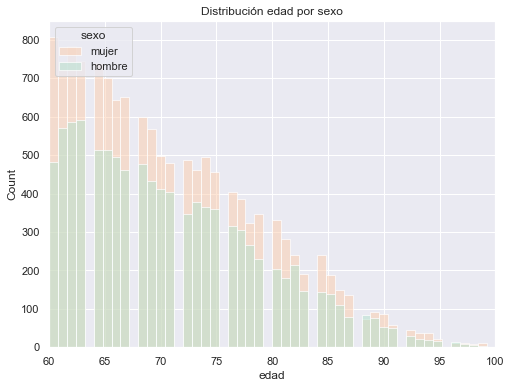

In [4974]:
#edad
sns.histplot(x= df['edad'], hue= df['sexo'], palette= 'Pastel2',binwidth = 0.8)
plt.title('Distribución edad por sexo')
plt.xlim(60,100)
plt.legend(title='sexo', loc='upper left', labels=['mujer', 'hombre'])

### Datos relacionados con la salud

In [4975]:
df['diabetes'] = df['diabetes'].replace(to_replace= [0,1],value=['no','si'])
df['trastorno_mental'] = df['trastorno_mental'].replace(to_replace= [0,1],value=['no','si'])

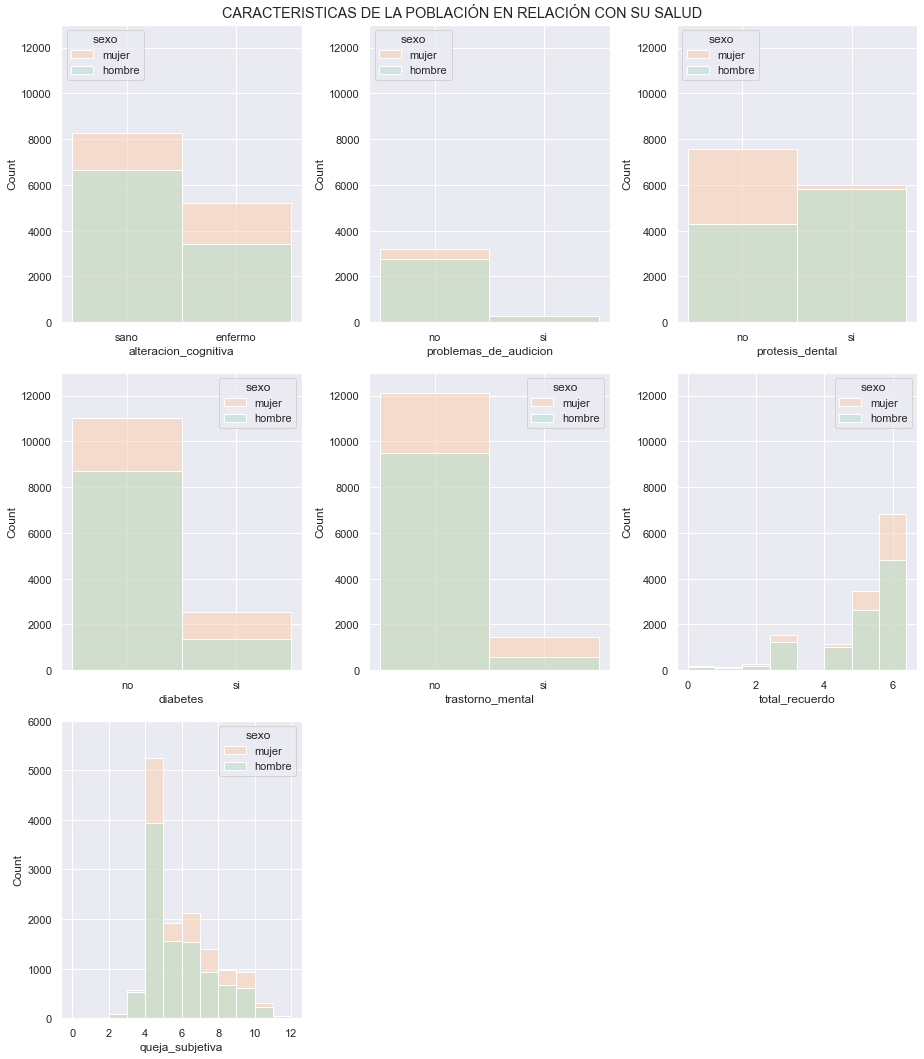

In [4976]:
fig, axes = plt.subplots(3, 3, figsize=(13, 15), sharey=False)
fig.suptitle('CARACTERISTICAS DE LA POBLACIÓN EN RELACIÓN CON SU SALUD')

# alteracion_cognitiva
sns.histplot(ax=axes[0][0],x= df['alteracion_cognitiva'], hue= df['sexo'], palette= 'Pastel2')
axes[0][0].legend(title='sexo', loc='upper left', labels=['mujer', 'hombre'])
axes[0][0].set_ylim(0,13000)

# problemas_de_audicion
sns.histplot(ax=axes[0][1],x= df['problemas_de_audicion'], hue= df['sexo'], palette= 'Pastel2',binwidth = 0.8)
axes[0][1].legend(title='sexo', loc='upper left', labels=['mujer', 'hombre'])
axes[0][1].set_ylim(0,13000)

#protesis_dental
sns.histplot(ax=axes[0][2],x= df['protesis_dental'], hue= df['sexo'], palette= 'Pastel2')
axes[0][2].legend(title='sexo', loc='upper left', labels=['mujer', 'hombre'])
axes[0][2].set_ylim(0,13000)


#diabetes
sns.histplot(ax=axes[1][0],x= df['diabetes'], hue= df['sexo'], palette= 'Pastel2')
axes[1][0].legend(title='sexo', loc='upper right', labels=['mujer', 'hombre'])
axes[1][0].set_ylim(0,13000)


#trastorno_mental
sns.histplot(ax=axes[1][1],x= df['trastorno_mental'], hue= df['sexo'], palette= 'Pastel2')
axes[1][1].legend(title='sexo', loc='upper right', labels=['mujer', 'hombre'])
axes[1][1].set_ylim(0,13000)

#total_recuerdo
sns.histplot(ax=axes[1][2],x= df['total_recuerdo'], hue= df['sexo'], palette= 'Pastel2', binwidth= 0.8)
axes[1][2].legend(title='sexo', loc='upper right', labels=['mujer', 'hombre'])
axes[1][2].set_ylim(0,13000)


#queja_subjetiva
sns.histplot(ax=axes[2][0],x= df['queja_subjetiva'], hue= df['sexo'], palette= 'Pastel2', binwidth= 1)
axes[2][0].legend(title='sexo', loc='upper right', labels=['mujer', 'hombre'])
axes[2][0].set_ylim(0,6000)


fig.delaxes(axes[2][1])
fig.delaxes(axes[2][2])



plt.tight_layout()
plt.show()


#### - VERIFICAR NÚMERO DE RESPUESTAS Y CAMPOS SIN CONTESTAR (NAN)

In [4977]:
#numero de respuestas
print(f'Número de respuestas en el formulario {len(df)}')

Número de respuestas en el formulario 23694


In [4978]:
#Respuestas en mayuscula a minuscula
df['medicamentos'] = df['medicamentos'].str.lower()
df['paraclinicos'] = df['paraclinicos'].str.lower()

In [4979]:
#NaNs en la base de datos
nan_en_col = df.isna().sum().sort_values(ascending=False)
nan_df = pd.DataFrame(nan_en_col)
nan_df.rename(columns={0:'NAN'}, inplace=True)

# Verificar columnas con valores NAN en la base de datos
# Columnas con 70%(16585) o más de los datos serán incluidas en la BD

columnas_excluidas = nan_df[nan_df['NAN'] >= 16585]
print(columnas_excluidas)

columnas_medio_nan = nan_df[(nan_df['NAN'] > 7000) & (nan_df['NAN'] < 16585)]
print(columnas_medio_nan)

columnas_bajo_nan = nan_df[(nan_df['NAN'] < 7000) & (nan_df['NAN'] > 0)]
print(columnas_bajo_nan)


                         NAN
fuerza_presion         18297
recibir_serv_salud     17614
problemas_de_audicion  17162
               NAN
paraclinicos  9745
trabaja       7845
                        NAN
grupo_etnico           5855
raza                   5554
percepcion             5441
rechazado              5101
sexualidad             4972
hambre15               4838
religioso              4818
ancianitud             4778
testigo15              4738
salud_adolescencia     4730
maltrato               4727
lastimado              4725
vision                 4723
robo                   4718
consumo_alcohol        4710
equilibrio             4081
ingresos               3736
IMC                    3469
medicamentos           3432
estado_civil           2681
velocidad_marcha       2278
vivienda                305
piso                    297
tipo_vivienda           295
alteracion_cognitiva    169
miedo_a_caer            135
busca_ayuda             100
diabetes                 90
trastorno_menta

In [4980]:
# Eliminar columnas con alto número de Nan
df.drop(columns= ['fuerza_presion','recibir_serv_salud', 'problemas_de_audicion'], axis = 1, inplace=True)

In [4981]:
# Remplazar Nan Values con media en Columnas que tienen por opción un rango numérico
df['velocidad_marcha'].fillna(df['velocidad_marcha'].mean(), inplace= True)
df['IMC'].fillna(df['IMC'].mean(), inplace= True)

# Verificar que no existan Na en dichas columnas
print(df['velocidad_marcha'].isna().value_counts())
print(df['IMC'].isna().value_counts())

False    23694
Name: velocidad_marcha, dtype: int64
False    23694
Name: IMC, dtype: int64


In [4982]:
# Revisar Nan en columnas para dummy y cols con más de una opcion
cols = ['grupo_etnico', 'raza', 'tipo_vivienda','consumo_alcohol','afiliacion','equilibrio'] 
for col in cols:
    counts = df[col].value_counts(normalize=True)
    nan_index = df[df[col].isna()].index
    values = counts.keys()
    samples = np.random.choice(values, len(nan_index), p= counts.values)
    df[col].loc[nan_index] = samples


In [4983]:
# Crear columnas dummy
cols = ['grupo_etnico', 'raza', 'tipo_vivienda','consumo_alcohol','afiliacion']
dummies = pd.get_dummies(df[cols])

In [4984]:
# Unir dummy a la BD
df = pd.concat((df,dummies), axis=1)

In [4985]:
# Verificar columnas con valores NAN en la base de datos
# Columnas con 70%(16585) o más de los datos serán incluidas en la BD

columnas_excluidas = nan_df[nan_df['NAN'] >= 16585]
print(columnas_excluidas)

columnas_medio_nan = nan_df[(nan_df['NAN'] > 7000) & (nan_df['NAN'] < 16585)]
print(columnas_medio_nan)

columnas_bajo_nan = nan_df[(nan_df['NAN'] < 7000) & (nan_df['NAN'] > 0)]
print(columnas_bajo_nan)


                         NAN
fuerza_presion         18297
recibir_serv_salud     17614
problemas_de_audicion  17162
               NAN
paraclinicos  9745
trabaja       7845
                        NAN
grupo_etnico           5855
raza                   5554
percepcion             5441
rechazado              5101
sexualidad             4972
hambre15               4838
religioso              4818
ancianitud             4778
testigo15              4738
salud_adolescencia     4730
maltrato               4727
lastimado              4725
vision                 4723
robo                   4718
consumo_alcohol        4710
equilibrio             4081
ingresos               3736
IMC                    3469
medicamentos           3432
estado_civil           2681
velocidad_marcha       2278
vivienda                305
piso                    297
tipo_vivienda           295
alteracion_cognitiva    169
miedo_a_caer            135
busca_ayuda             100
diabetes                 90
trastorno_menta

In [4986]:
df['piso_num']= df['piso'].map({'bajo ingreso': 0, 'alto ingreso': 1}).astype('Int64')
df['vivienda_num']= df['vivienda'].map({'propia': 0, 'otra': 1}).astype('Int64')
df['sexualidad_num']= df['sexualidad'].map({'poco': 0, 'importante': 1}).astype('Int64')
df['estado_civil_num'] = df['estado_civil'].map({'separado/viudo': 0, 'casado/unido': 1}).astype('Int64')
df['ingresos_num'] = df['ingresos'].map({'0-1SM': 0, '>2SM': 1}).astype('Int64')
df['ha_fumado_num'] = df['ha_fumado'].map({'nunca': 0, 'si': 1}).astype('Int64')

In [4987]:
# Reemplazar valores categoricos a numéricos
cols_alteradas = []
suffix = '_num'
for column in df.columns:
    if  df[column].isin(['sano','enfermo']).any():
        new_col = column + suffix
        df[new_col] = df[column].map({'sano': 1, 'enfermo': 0}).astype('Int64')
        cols_alteradas.append(f'sano {new_col}')
    if df[column].isin(['si','no','mucho']).any():
        new_col = column + suffix
        df[new_col]= df[column].map({'si': 1, 'no': 0, 'mucho':1, 'nunca':0}).astype('Int64')
        cols_alteradas.append(f'no/si {new_col}')
    if df[column].isin(['mala','buena']).any():
        new_col = column + suffix
        df[new_col] = df[column].map({'mala': 0, 'buena': 1}).astype('Int64')
        cols_alteradas.append(f'mala/buna {new_col}')

In [4988]:
print(cols_alteradas)

['no/si ha_trabajado_num', 'no/si trabaja_num', 'no/si afiliacion_num', 'no/si salud_30dias_num', 'no/si medicamentos_num', 'no/si paraclinicos_num', 'no/si busca_ayuda_num', 'no/si ha_fumado_num', 'no/si diabetes_num', 'no/si trastorno_mental_num', 'mala/buna vision_num', 'no/si oir_en_multitudes_num', 'no/si protesis_dental_num', 'no/si caida_num', 'no/si miedo_a_caer_num', 'no/si ancianitud_num', 'no/si percepcion_num', 'no/si religioso_num', 'no/si participacion_en_grupos_num', 'no/si ayudainstitucional_num', 'no/si voluntariado_num', 'no/si maltrato_num', 'no/si robo_num', 'no/si lastimado_num', 'no/si desplazado_num', 'no/si rechazado_num', 'mala/buna salud_adolescencia_num', 'no/si hambre15_num', 'no/si testigo15_num', 'sano barthel_dic_num', 'sano alteracion_cognitiva_num']


In [4989]:
# Escolaridad en años y grado alcanzado no se corresponden
df[['escolaridad_en_anos','grado_alcanzado']]

,escolaridad_en_anos,grado_alcanzado
0,0,5
1,5,3
2,1,2
3,1,2
4,2,2
...,...,...
23689,2,2
23690,0,9
23691,3,2
23692,1,2


In [4990]:
#valores máximos de escolaridad en años y grado alcanzado son 99/98?
print(df['escolaridad_en_anos'].max())
print(df['grado_alcanzado'].max())

99
99


In [4991]:
#Borrar escolaridad en años y grado alcanzado 
df.drop(['escolaridad_en_anos','grado_alcanzado'], axis=1, inplace=True)

In [4992]:
# Verificar que la base tenga unicamente datos numéricos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23694 entries, 0 to 23693
Columns: 121 entries, ha_trabajado to alteracion_cognitiva_num
dtypes: Int64(36), float64(6), int64(19), object(40), uint8(20)
memory usage: 19.5+ MB


In [4993]:
# Economia familiar no se corresponde con la descripcion del codebook(En vez de buena/mala/regular tiene valores continuos de 0 a 7).
# Vamos a eliminarla para este análisis (Discutirlo)
df.drop(columns='economia_familiar', inplace=True) 

In [4994]:
df.head()

,ha_trabajado,edad_primer_trabajo,ingresos,trabaja,area_vivienda,piso,vivienda,tipo_vivienda,afiliacion,servicios,...,maltrato_num,robo_num,lastimado_num,desplazado_num,rechazado_num,salud_adolescencia_num,hambre15_num,testigo15_num,barthel_dic_num,alteracion_cognitiva_num
0,si,17,0-1SM,NaN,1,alto ingreso,propia,casa/apto,si,4,...,1,0,0,0,0,1,1,1,1,1
1,si,20,0-1SM,no,1,alto ingreso,propia,casa/apto,si,4,...,0,0,0,0,0,1,1,0,1,0
2,si,18,0-1SM,no,1,alto ingreso,otra,casa/apto,subsidiado,4,...,0,0,0,0,0,1,1,0,1,0
3,si,7,0-1SM,no,1,alto ingreso,propia,casa/apto,subsidiado,4,...,0,0,0,1,0,0,1,0,1,1
4,si,15,0-1SM,no,1,alto ingreso,propia,casa/apto,subsidiado,4,...,0,0,0,0,0,1,1,0,1,1


### LLENAR Nan SIGUIENDO LAS DISTRIBUCIONES DE LAS COLUMNAS EN COLUMNAS CON VALORES BINARIOS

In [4995]:
# Remplazar valores Nan con respuestas respetando el porcentaje si/no de la BD original  
for col in df[['infarto_miocardio','paraclinicos_num','trabaja_num','alteracion_cognitiva_num','medicamentos_num','percepcion_num', 'rechazado_num', 'sexualidad_num','hambre15_num','religioso_num','ancianitud_num','testigo15_num','salud_adolescencia_num','maltrato_num','lastimado_num','vision_num','robo_num','ingresos_num','estado_civil','vivienda','piso','miedo_a_caer_num','busca_ayuda_num','diabetes_num','trastorno_mental_num','hipertension_arterial','stroke','barthel_dic_num','salud_30dias_num','ha_fumado_num','desplazado_num']]:
    print(col)
    valor_mayor = df[col].value_counts().max()
    valor_menor = df[col].value_counts().min()
    respuesta_mayor = df[col].value_counts().index[0]
    respuesta_menor = df[col].value_counts().index[1]

    porcentaje_menor = (valor_menor/valor_mayor)
    nan_vals = df[col].isna() 
    nan_index = df[col].loc[nan_vals].sample(frac=porcentaje_menor).index
    df.loc[nan_index, col] = respuesta_menor
    df[col] = df[col].fillna(respuesta_mayor)


infarto_miocardio
paraclinicos_num
trabaja_num
alteracion_cognitiva_num
medicamentos_num
percepcion_num
rechazado_num
sexualidad_num
hambre15_num
religioso_num
ancianitud_num
testigo15_num
salud_adolescencia_num
maltrato_num
lastimado_num
vision_num
robo_num
ingresos_num
estado_civil
vivienda
piso
miedo_a_caer_num
busca_ayuda_num
diabetes_num
trastorno_mental_num
hipertension_arterial
stroke
barthel_dic_num
salud_30dias_num
ha_fumado_num
desplazado_num


In [4996]:
nan_en_col_after = df.isna().sum().sort_values(ascending=False)
nan_df_after = pd.DataFrame(nan_en_col_after)
nan_df_after.rename(columns={0:'NAN'}, inplace=True )
columnas_bajo_nan_after = nan_df_after[(nan_df_after['NAN'] < 7000) & (nan_df_after['NAN'] > 0)]
print(columnas_bajo_nan_after)

                       NAN
percepcion            5441
rechazado             5101
sexualidad            4972
hambre15              4838
religioso             4818
ancianitud            4778
testigo15             4738
salud_adolescencia    4730
maltrato              4727
lastimado             4725
vision                4723
robo                  4718
ingresos              3736
medicamentos          3432
estado_civil_num      2681
vivienda_num           305
piso_num               297
alteracion_cognitiva   169
miedo_a_caer           135
busca_ayuda            100
diabetes                90
trastorno_mental        65
barthel_dic             26
salud_30dias            12
ha_fumado                8
desplazado               5


### EXPLORACION DE LAS VARIABLES MINIMENTAL TOTAL Y ESCALA QUEJA SUBJETIVA 

In [4997]:
#Escala minimental
print(f'La escala de queja subjetiva va de valor minimo {df["minimental_total"].min()}, a valor maximo {df["minimental_total"].max()}')

La escala de queja subjetiva va de valor minimo 0, a valor maximo 30


In [4998]:
#escala queja subjetiva
print(f'La escala de queja subjetiva va de valor minimo {df["queja_subjetiva"].min()}, a valor maximo {df["queja_subjetiva"].max()}')

La escala de queja subjetiva va de valor minimo 0, a valor maximo 12


Entre 30 y 27 puntos: No existe deterioro cognitivo.
Entre 26 y 25 puntos: Existen dudas o pudiera existir un posible deterioro cognitivo.
Entre 24 y 10 puntos: Existe un deterioro cognitivo de leve a moderado.
Entre 9 y 6 puntos: Existe un deterioro cognitivo de moderado a severo.
Menos de 6 puntos: Deterioro cognitivo severo.

In [4999]:
# copiar el DF original
df_norm = df.copy()
  
# aplicar normalización en las columnas con valores numéricos
columnas = ['velocidad_marcha','IMC','GDS','num_personas_casa','edad_desplazamiento','num_desplazamientos','auto_salud','equilibrio','barthel_total','lawton_total', 'minimental_total', 'queja_subjetiva', 'total_orientacion', 'total_recuerdo', 'calculo','lenguaje']
for cols in columnas:
    print(cols)
    df_norm[cols] = MinMaxScaler().fit_transform(np.array(df[cols]).reshape(-1,1))
  
# ver la BD normalizada
df_norm.head(5)

velocidad_marcha
IMC
GDS
num_personas_casa
edad_desplazamiento
num_desplazamientos
auto_salud
equilibrio
barthel_total
lawton_total
minimental_total
queja_subjetiva
total_orientacion
total_recuerdo
calculo
lenguaje


,ha_trabajado,edad_primer_trabajo,ingresos,trabaja,area_vivienda,piso,vivienda,tipo_vivienda,afiliacion,servicios,...,maltrato_num,robo_num,lastimado_num,desplazado_num,rechazado_num,salud_adolescencia_num,hambre15_num,testigo15_num,barthel_dic_num,alteracion_cognitiva_num
0,si,17,0-1SM,NaN,1,alto ingreso,propia,casa/apto,si,4,...,1,0,0,0,0,1,1,1,1,1
1,si,20,0-1SM,no,1,alto ingreso,propia,casa/apto,si,4,...,0,0,0,0,0,1,1,0,1,0
2,si,18,0-1SM,no,1,alto ingreso,otra,casa/apto,subsidiado,4,...,0,0,0,0,0,1,1,0,1,0
3,si,7,0-1SM,no,1,alto ingreso,propia,casa/apto,subsidiado,4,...,0,0,0,1,0,0,1,0,1,1
4,si,15,0-1SM,no,1,alto ingreso,propia,casa/apto,subsidiado,4,...,0,0,0,0,0,1,1,0,1,1


In [5000]:
# Eliminar la redundancia de la nueva df
df_norm.drop(['grupo_etnico', 'raza', 'tipo_vivienda','consumo_alcohol','afiliacion'], axis=1, inplace= True)

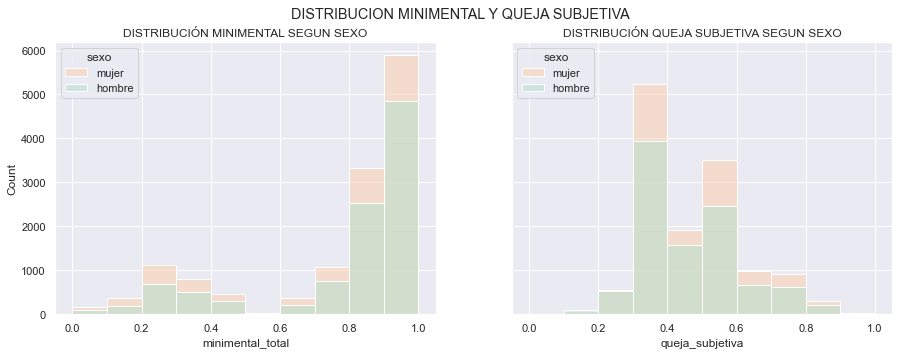

In [5001]:
# Histograma distribucion minimental

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
fig.suptitle('DISTRIBUCION MINIMENTAL Y QUEJA SUBJETIVA')

# Minimental
sns.histplot(ax=axes[0],data= df_norm, x = 'minimental_total',hue= 'sexo', palette= 'Pastel2',binwidth = 0.1)
axes[0].set_title('DISTRIBUCIÓN MINIMENTAL SEGUN SEXO')
axes[0].legend(title='sexo', loc='upper left', labels=['mujer', 'hombre'])

# Queja Subjetiva
sns.histplot(ax=axes[1],data= df_norm, x = 'queja_subjetiva', hue= 'sexo', palette= 'Pastel2',binwidth = 0.1)
axes[1].set_title('DISTRIBUCIÓN QUEJA SUBJETIVA SEGUN SEXO')
axes[1].legend(title='sexo', loc='upper left', labels=['mujer', 'hombre'])


plt.show()

In [5002]:
#Correlation between the variables
correlacion = np.corrcoef(df_norm['queja_subjetiva'],df_norm['minimental_total'])
correlacion

array([[1.        , 0.32894829],
       [0.32894829, 1.        ]])

Text(0.5, 1.0, 'CORRELACION ENTRE QUEJA SUBJETIVA Y MINIMENTAL')

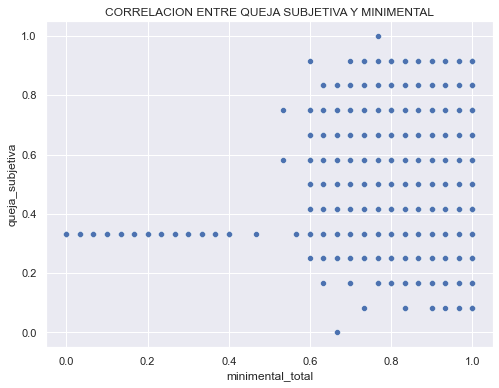

In [5003]:
sns.scatterplot(df_norm['minimental_total'],df_norm['queja_subjetiva'])
plt.title('CORRELACION ENTRE QUEJA SUBJETIVA Y MINIMENTAL')

In [5004]:
columnas = ['ha_trabajado', 'edad_primer_trabajo', 'ingresos', 'trabaja',
       'area_vivienda', 'piso', 'vivienda', 'servicios', 'salud_30dias',
       'medicamentos','ha_fumado', 'velocidad_marcha', 'IMC', 'stroke', 'infarto_miocardio', 'diabetes', 
       'GDS', 'trastorno_mental','vision', 'oir_en_multitudes', 'protesis_dental', 'caida','miedo_a_caer', 'ancianitud', 
       'percepcion', 'sexualidad', 'religioso','estado_civil', 'participacion_en_grupos', 'ayudainstitucional', 'voluntariado', 
       'num_personas_casa', 'sexo', 'edad', 'maltrato', 'robo',
       'lastimado', 'desplazado', 'edad_desplazamiento', 'num_desplazamientos',
       'rechazado', 'salud_adolescencia', 'hambre15', 'testigo15',
       'auto_salud', 'equilibrio', 'barthel_total', 'barthel_dic',
       'lawton_total','queja_subjetiva', 'total_orientacion', 'total_recuerdo', 'calculo',
       'lenguaje', 'grupo_etnico', 'raza', 'tipo_vivienda',
       'consumo_alcohol', 'afiliacion']

len(columnas)

59

In [5005]:
df['sexo'] = df['sexo'].replace(to_replace= [1,2],value=['hombre','mujer'])
df['stroke'] = df['stroke'].replace(to_replace= [0,1],value=['no','si'])
df['infarto_miocardio'] = df['infarto_miocardio'].replace(to_replace= [0,1],value=['no','si'])

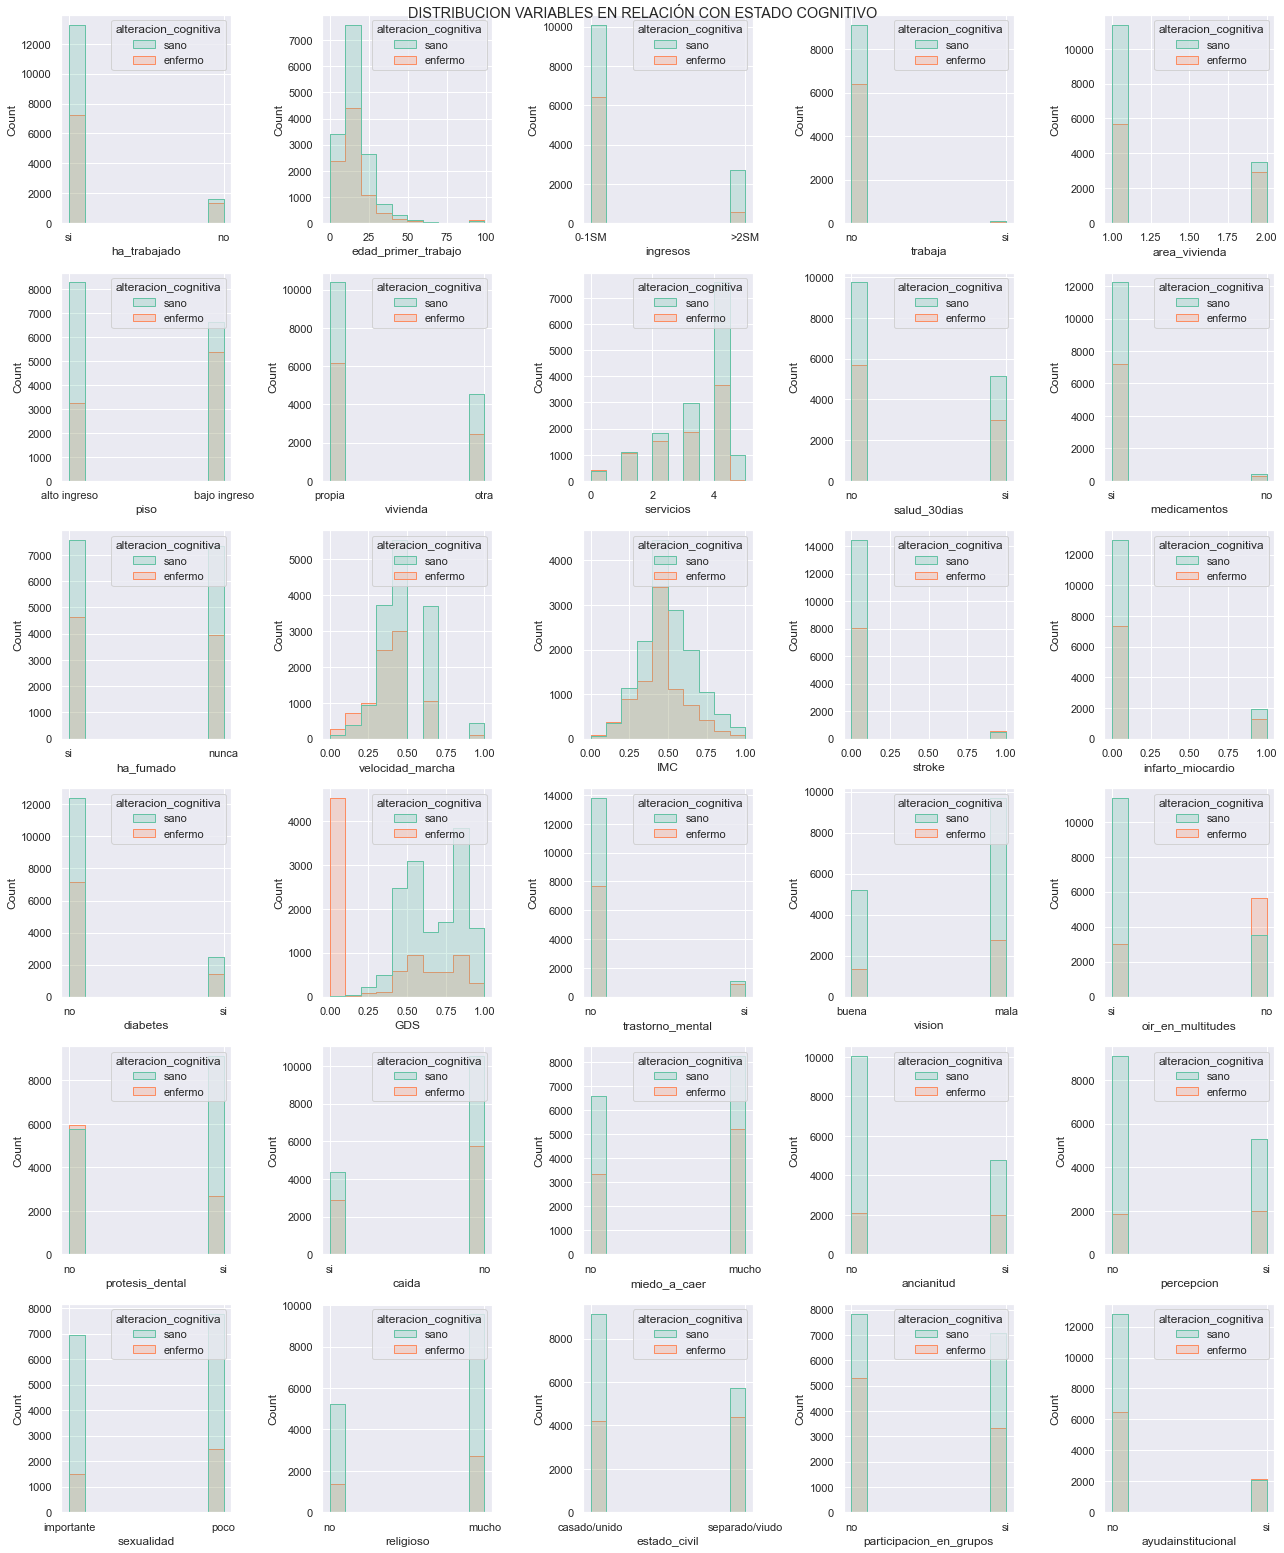

In [5026]:
#plot relacion entre columnas y nivel de alteración cognitiva con datos originales
plt.figure(figsize=(18,22))
plt.suptitle('DISTRIBUCION VARIABLES EN RELACIÓN CON ESTADO COGNITIVO')


for i in range(len(columnas[:30])):
   ax =plt.subplot(6,5,i+1)
   sns.histplot(data = df_norm, x = columnas[i], hue = 'alteracion_cognitiva', bins = 10, element="step",palette= 'Set2', ax= ax, discrete=False)
plt.tight_layout()
plt.show()

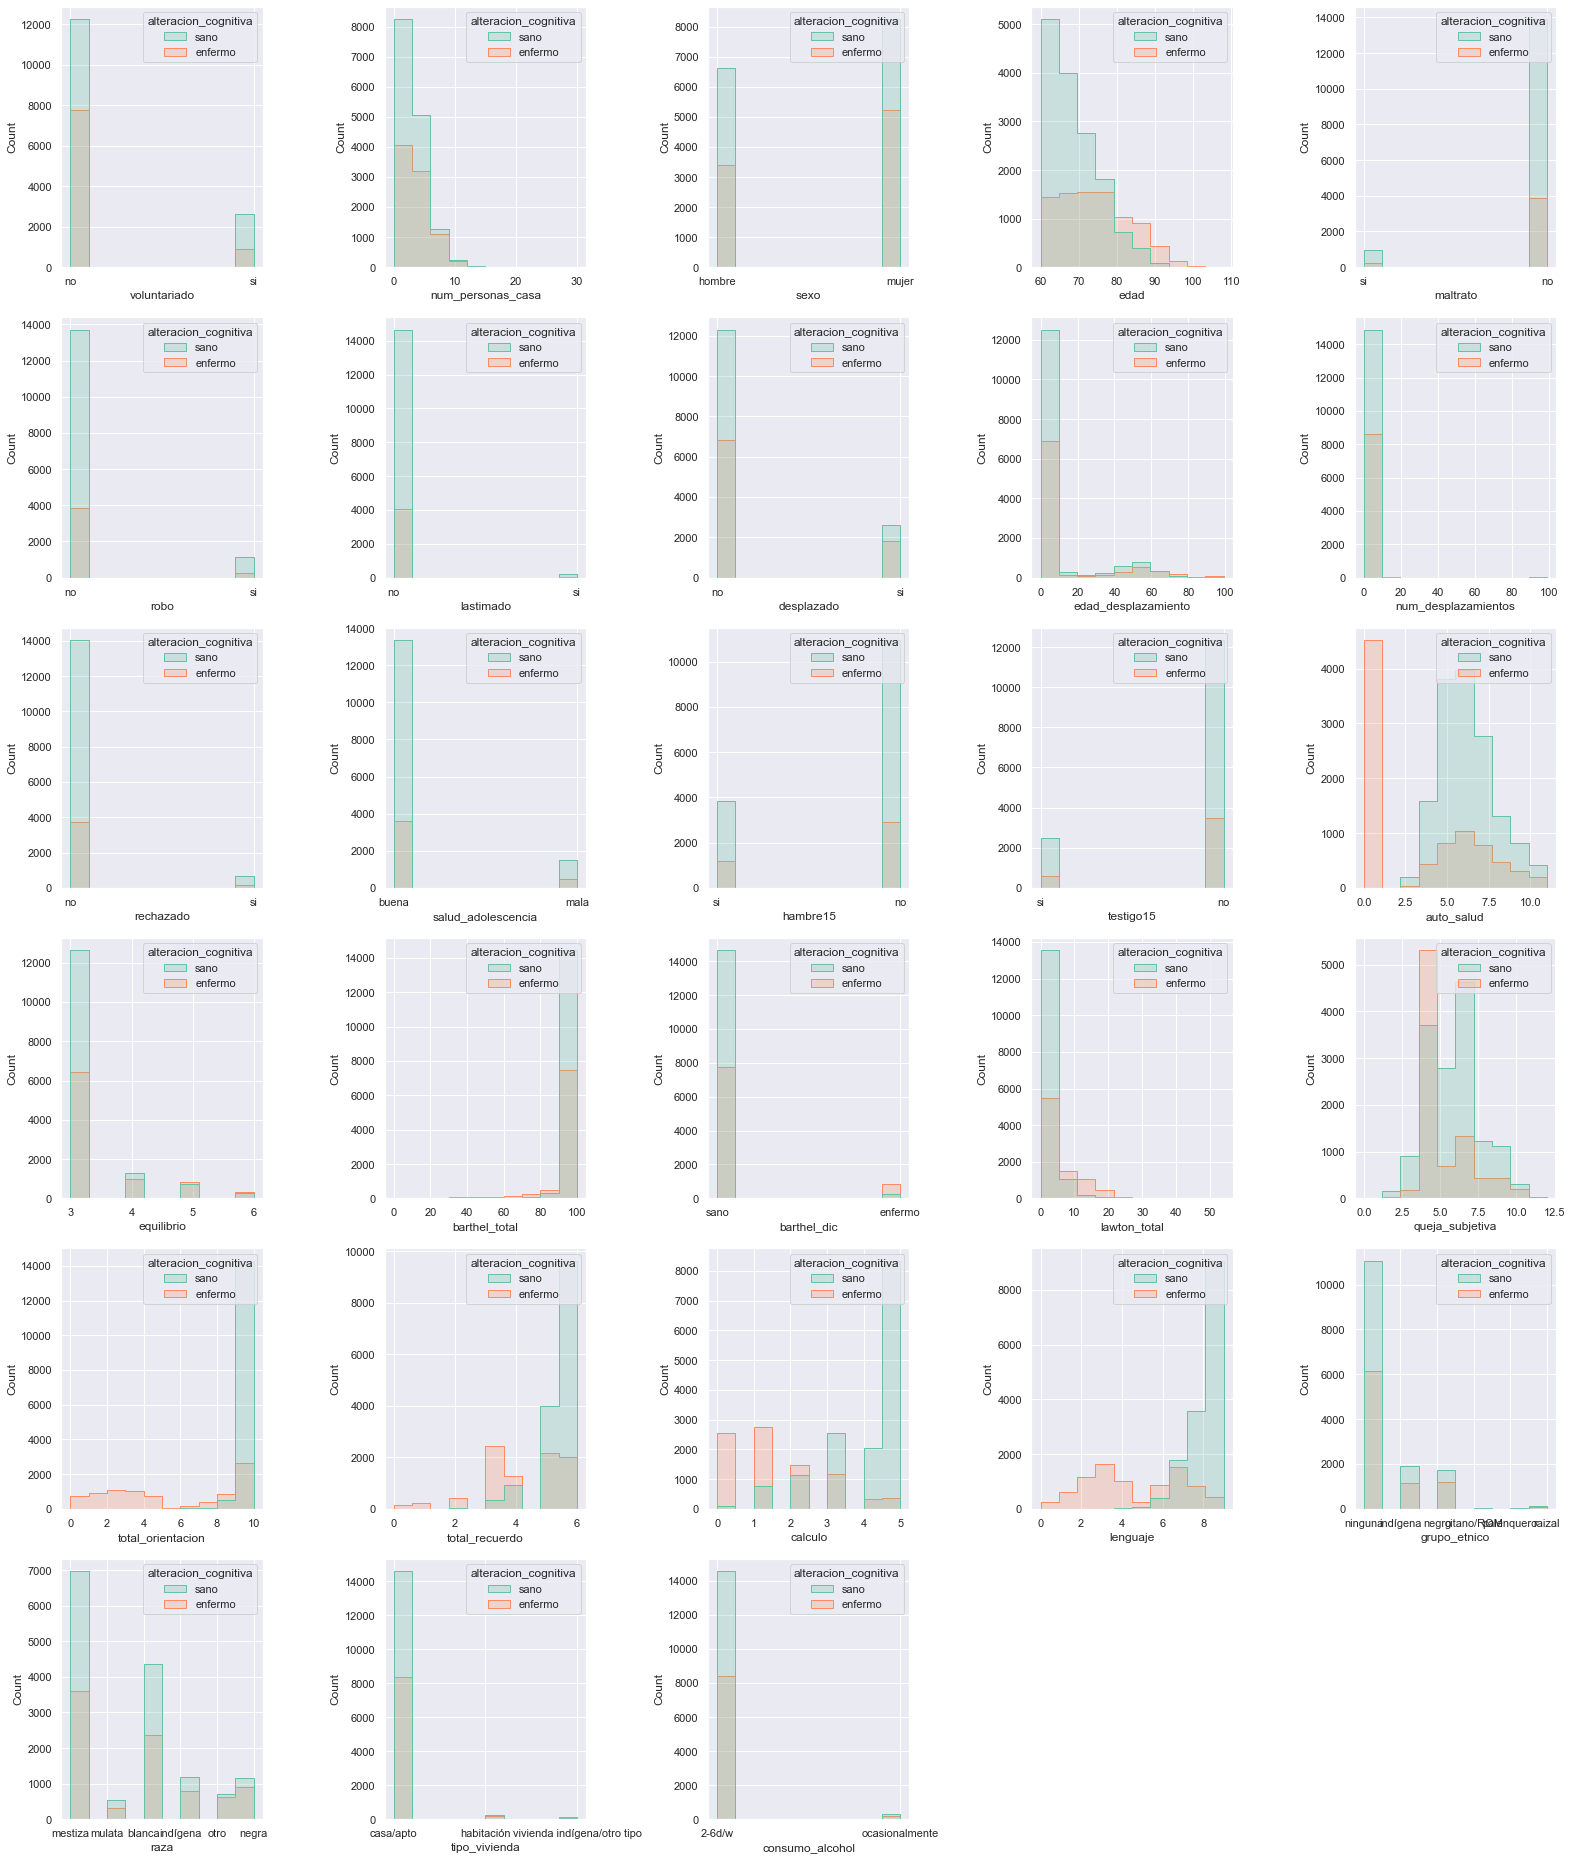

In [5024]:
#plot relacion entre columnas y nivel de alteración cognitiva


plt.figure(figsize=(22,26))
fig.suptitle('DISTRIBUCION VARIABLES EN RELACIÓN CON ESTADO COGNITIVO')

for i in range(len(columnas[31:])):
   ax =plt.subplot(6,5,i+1)
   sns.histplot(data = df, x = columnas[i+30], hue = 'alteracion_cognitiva', bins = 10, element="step",palette= 'Set2', ax= ax,discrete=False)

plt.tight_layout()
plt.show()

### Creación columna coherencia. 
Si tiende a 0 la persona tiene una autoevaluación incoherente con su desempeño cognitivo objetivo. Coherente si tiende a 1.

In [5008]:
# Creacion de variable coherencia entre queja subjetiva y minimental 
#coherencia = alteracion_cognitiva_real - queja_subjetiva
df_norm['coherencia'] =  df_norm['minimental_total']- df_norm['queja_subjetiva']

In [5037]:
# Normalizamos la columna
df_norm['coherencia'] = (df_norm['coherencia'] - df_norm['coherencia'].min()) / (df_norm['coherencia'].max() - df_norm['coherencia'].min()) 

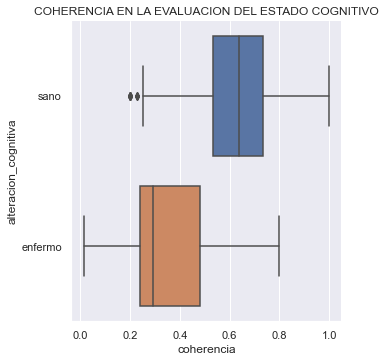

In [5052]:
sns.catplot(data=df_norm, y="alteracion_cognitiva", x="coherencia", kind = 'box', palette='Set2').set(title= 'COHERENCIA EN LA EVALUACION DEL ESTADO COGNITIVO')

In [5064]:
df_norm['sexo'] = df_norm['sexo'].replace(to_replace= [1,2],value=['hombre','mujer'])

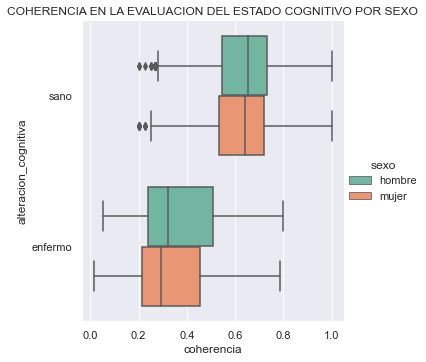

In [5065]:
sns.catplot(data=df_norm, y="alteracion_cognitiva", x="coherencia", kind = 'box', hue='sexo', palette= 'Set2').set(title= 'COHERENCIA EN LA EVALUACION DEL ESTADO COGNITIVO POR SEXO')
plt.show()